### we are creating a project that will comapre different models(Navie byes, logistics Regression and SVM) and comapre them based on their performance and give you the best model.
#### we are using twitter sentiment analysis dataset for this project

In [7]:
# importing all the required libraries
import pandas as pd              # For data handling
import numpy as np               # For numerical operations
import re                        # For text cleaning (regex)
import nltk                      # NLP toolkit
import pickle                    # To save/load models

# NLTK tools
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import contractions
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Scikit-learn tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Machine Learning Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# remove warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_d

In [8]:
# upload the dataset
df = pd.read_csv('sentiment_dataset.csv')

In [9]:
#check the first few rows of the dataset
df.head()

,sentiment,review
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...


In [10]:
# check the sentiment distribution
df['sentiment'].value_counts()

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

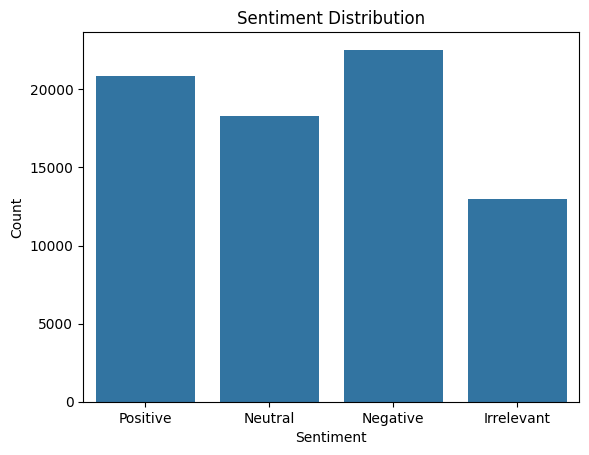

In [11]:
# plot the sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [12]:
#checking information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  74681 non-null  object
 1   review     73995 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [13]:
# checking for missing values
df.isnull().sum()

sentiment      0
review       686
dtype: int64

In [14]:
# since we got some missing values in the review column, we will drop those rows
df.dropna(subset=['review'], inplace=True)

In [15]:
#again check for missing values
df.isnull().sum()

sentiment    0
review       0
dtype: int64

In [16]:
#checking for duplicates
df.duplicated().sum()

4229

In [17]:
#we also got some duplicate rows, we will drop those as well
df.drop_duplicates(inplace=True)

In [18]:
#again check for duplicates
df.duplicated().sum()

0

### these steps are performed beacuse the dataset is too much big and will takes time to train

In [19]:
# check the length of the shortest and longest review after preprocessing
print("Shortest review length:", df['review'].apply(len).min())
print("Longest review length:", df['review'].apply(len).max())

Shortest review length: 1
Longest review length: 957


In [20]:
# creating a function that will remove characters less than 10 and greater than 200
def remove_short_long_reviews(text):
    """
    Remove reviews that are too short or too long
    based on WORD COUNT (better than character count)
    """
    
    # Handle missing or non-string values safely
    if not isinstance(text, str):
        return np.nan
    
    # Count number of words instead of characters
    word_count = len(text.split())
    
    # Filter condition
    if word_count < 30 or word_count > 150:
        return np.nan
    
    return text

In [21]:
# apply thre function to the review column
df['review'] = df['review'].apply(remove_short_long_reviews)

In [22]:
# drop the rows with NaN values after filtering
df = df.dropna(subset=['review']).reset_index(drop=True)

In [23]:
# now check the number of reviews
print("Number of reviews after preprocessing:", len(df))

Number of reviews after preprocessing: 15675


In [24]:
#checking the head of the dataset after preprocessing
df.head()

,sentiment,review
0,Positive,So I spent a few hours making something for fu...
1,Positive,So I spent a couple of hours doing something f...
2,Positive,So I spent a few hours making something for fu...
3,Positive,2010 So I spent a few hours making something f...
4,Positive,that I was the first real borderlands session ...


#### preprocessing

In [25]:
# preprocess the text data using advance text cleaning techniques to improve the performance of the models
# Load stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Advanced NLP preprocessing pipeline:
    - Lowercasing
    - Remove URLs and HTML tags
    - Normalize currency and numbers
    - Remove special characters
    - Tokenization (NLTK)
    - POS tagging
    - Lemmatization with POS
    - Stopword removal
    - Remove short tokens
    - Clean extra spaces
    """
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # 4. Normalize currency (e.g., $100.50 → money)
    text = re.sub(r'\$\s?\d+(\.\d+)?', ' money ', text)
    
    # 5. Normalize numbers (e.g., 123 → number)
    text = re.sub(r'\d+(\.\d+)?', ' number ', text)
    
    # 6. Remove special characters & punctuation
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 7. Tokenization using NLTK
    tokens = word_tokenize(text)
    
    # 8. POS tagging
    pos_tags = pos_tag(tokens)
    
    # 9. Helper function for POS conversion (inside function as requested)
    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return 'a'  # adjective
        elif tag.startswith('V'):
            return 'v'  # verb
        elif tag.startswith('N'):
            return 'n'  # noun
        elif tag.startswith('R'):
            return 'r'  # adverb
        else:
            return 'n'
    
    # 10. Lemmatization + stopword removal + short word filtering
    cleaned_words = []
    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos)
            cleaned_words.append(lemma)
    
    # 11. Join tokens
    text = ' '.join(cleaned_words)
    
    # 12. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [26]:
# apply the preprocessing function to the reviews
df['review'] = df['review'].apply(preprocess_text)

In [27]:
# now we will split the dataset into features and target variable
X = df['review']  # Features (reviews)
y = df['sentiment']  # Target variable (sentiment)

In [28]:
# we will convert the target variable into numerical format using LabelEncoder and save the encoder for later use
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

In [29]:
# lets see the mapping of the labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)

Label Mapping: {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


In [30]:
# checking the shape of the features and target variable
print("Features shape:", X.shape)
print("Target variable shape:", y.shape)

Features shape: (15675,)
Target variable shape: (15675,)


In [31]:
# apply TFIDF vectorization to convert text data into numerical format
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to top 5000 features
X = vectorizer.fit_transform(df['review']).toarray()

In [32]:
# train test split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
# initilize the models
models = {
    'MultinomialNB': MultinomialNB(),
    'SVC': SVC(kernel='linear', random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=100, random_state=42)
}

In [34]:
# train and evaluate each model
results = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average='weighted'),
        "recall": recall_score(y_test, y_pred, average='weighted'),
        "f1": f1_score(y_test, y_pred, average='weighted'),
        "y_pred": y_pred
    }

In [35]:
# train all models and evaluate
for name, model in models.items():
    evaluate_model(name, model)

In [36]:
#get the result for comparison of all the models
results_df = pd.DataFrame({
    name: {
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1 Score": res["f1"]
    }
    for name, res in results.items()
}).T

print(results_df)

                    Accuracy  Precision    Recall  F1 Score
MultinomialNB       0.713876   0.739947  0.713876  0.706409
SVC                 0.859968   0.860447  0.859968  0.859693
LogisticRegression  0.806380   0.807038  0.806380  0.804872


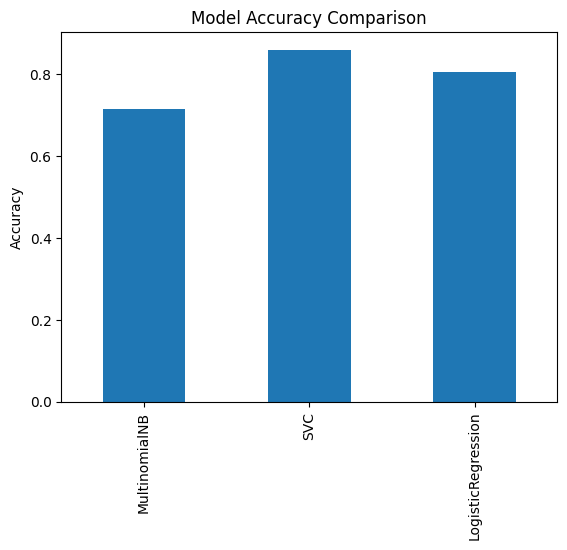

In [37]:
#plotting the accuracy of all the models
results_df["Accuracy"].plot(kind='bar')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

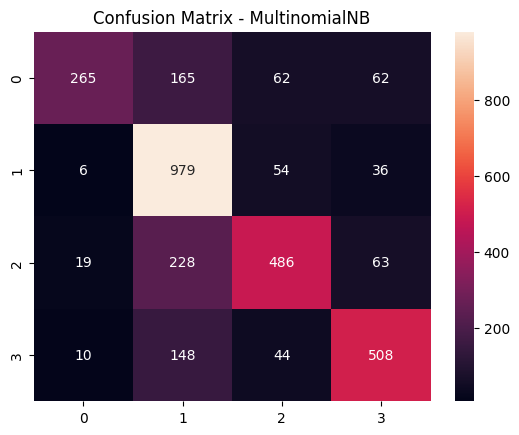

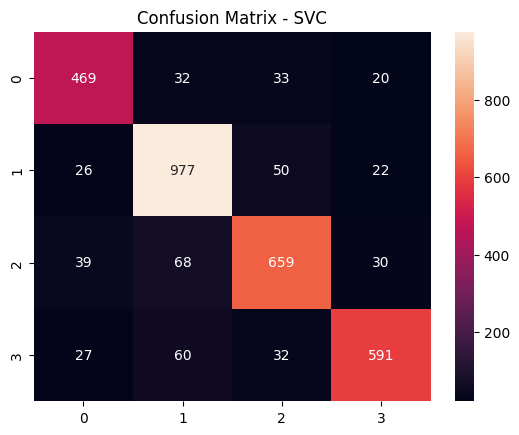

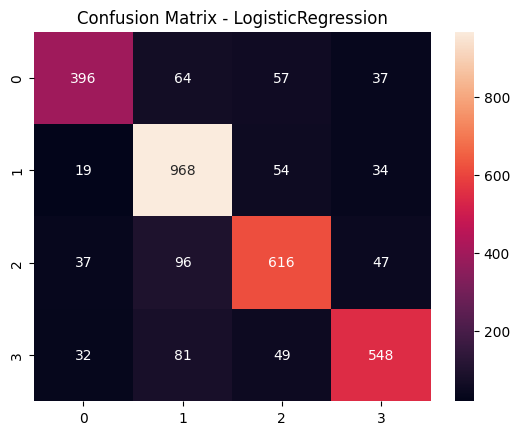

In [38]:
# plotting the confusion matrix for each model
for name, res in results.items():
    cm = confusion_matrix(y_test, res["y_pred"])
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [39]:
# cross validation for the best model
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} CV Score: {scores.mean()}")

MultinomialNB CV Score: 0.4249441786283891
SVC CV Score: 0.3928548644338118
LogisticRegression CV Score: 0.4061881977671451


In [40]:
#apply grid search for hyperparameter tuning on the best model.
param_grid = {
    "C": [0.1, 1, 10]
}

grid = GridSearchCV(LogisticRegression(max_iter=200), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 10}


In [41]:
# it will give us the best model and best model name based on accuracy
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
best_model = results[best_model_name]["model"]

In [42]:
# this will apply tuning to the selected best model and give us the best model after tuning
if best_model_name == "LogisticRegression":
    grid = GridSearchCV(
        LogisticRegression(max_iter=200),
        {"C": [0.1, 1, 10]},
        cv=3
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

elif best_model_name == "SVM":
    grid = GridSearchCV(
        SVC(kernel='linear'),
        {"C": [0.1, 1, 10]},
        cv=3
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

elif best_model_name == "NaiveBayes":
    # NB usually doesn't need tuning
    best_model = best_model

In [43]:
# saving the best model and the vectorizer for later use using pickle
pickle.dump(models, open('all_models.pkl', 'wb'))
pickle.dump(best_model_name, open('best_model_name.pkl', 'wb'))
pickle.dump(best_model, open('best_model.pkl', 'wb'))
pickle.dump(vectorizer, open('tfidf_vectorizer.pkl', 'wb'))

In [44]:
# creating a prediction system to predict the sentiment of new reviews using the best model and the vectorizer
def predict(text):
    text = preprocess_text(text)
    vec = vectorizer.transform([text]).toarray()

    predictions = {}

    for name, res in results.items():
        pred = res["model"].predict(vec)[0]
        predictions[name] = pred
        print(f"{name}: {pred}")

    print(f"\nBest Model: {best_model_name}")
    print(f"Best Model Prediction: {predictions[best_model_name]}")